In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pykalman import KalmanFilter
from hmmlearn import hmm

In [3]:
# 1. Load du lieu
df = pd.read_csv("ecg.csv")
X = df.iloc[:, :-1].values  # 140 diem ECG
y = df.iloc[:, -1].values   # Label: 0 binh thuong, 1 bat thuong

In [5]:
# 2. Chuan hoa du lieu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# 3. Lam muot bang Kalman Filter
kf = KalmanFilter(transition_matrices=[1],
                  observation_matrices=[1],
                  initial_state_mean=0,
                  initial_state_covariance=1,
                  observation_covariance=1,
                  transition_covariance=0.01)

X_smoothed = []
for signal in X_scaled:
    smoothed, _ = kf.smooth(signal)
    X_smoothed.append(smoothed.ravel())
X_smoothed = np.array(X_smoothed)

In [9]:
# 4. Tach tap huan luyen va test
X_train, X_test, y_train, y_test = train_test_split(X_smoothed, y, test_size=0.2, random_state=4242)

In [19]:
# 5. Huan luyen HMM tren du lieu binh thuong
X_normal = X_train[y_train == 0]
X_normal_reshaped = np.vstack([x.reshape(-1, 1) for x in X_normal])
lengths = [X_normal.shape[1]] * X_normal.shape[0]  # moi chuoi dai 140 diem

model = hmm.GaussianHMM(n_components=4, covariance_type="diag", n_iter=100)
model.fit(X_normal_reshaped, lengths)

GaussianHMM(n_components=4, n_iter=100)

In [22]:
# 6. Phat hien bat thuong tren tap test
scores = []
for sample in X_test:
    score = model.score(sample.reshape(-1, 1))
    scores.append(score)

threshold = np.percentile(scores, 5)  # nguong phat hien bat thuong
preds = [1 if s < threshold else 0 for s in scores]

In [23]:
# 7. Danh gia
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[390  30]
 [560  20]]
              precision    recall  f1-score   support

         0.0       0.41      0.93      0.57       420
         1.0       0.40      0.03      0.06       580

    accuracy                           0.41      1000
   macro avg       0.41      0.48      0.32      1000
weighted avg       0.40      0.41      0.28      1000



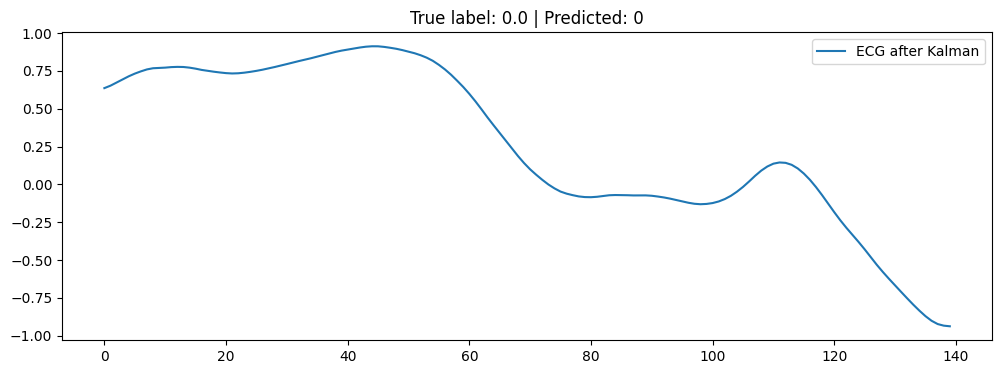

In [24]:
# 8. Truc quan hoa mot vai mau
plt.figure(figsize=(12, 4))
plt.plot(X_test[0], label="ECG after Kalman")
plt.title(f"True label: {y_test[0]} | Predicted: {preds[0]}")
plt.legend()
plt.show()